# Anatomy of the signal final state

The signal process is $gg \to B_s \to Z_d Z_d$, a heavy pseudoscalar
darkonium bound state ($m_{B_s}$ = 100-1000 GeV) decaying to two light dark
photons ($m_{Z_d}$ = 0.25-5 GeV), each of which decays to a collimated,
possibly displaced lepton pair. Everything characteristic about the final
state follows from the mass hierarchy $m_{Z_d} \ll m_{B_s}$:

1. each dark photon carries a boost $\beta\gamma \approx m_{B_s}/(2 m_{Z_d})$
   of order $10$-$10^3$;
2. the boost collimates the lepton pair to
   $\Delta R(\ell,\ell) \approx 2 \beta^* m_{Z_d}/p_T(Z_d)$ (with $\beta^*$
   the daughter velocity in the pair rest frame), inside the
   $\Delta R = 0.4$ lepton-jet clustering cone across the grid -- by a
   factor $\sim 700$ at the most collimated point and $\sim 1.5$ at the
   widest;
3. the two dark photons recoil against each other,
   $\Delta\phi(Z_d, Z_d) \approx \pi$;
4. the same boost stretches the proper lifetime into laboratory
   displacements $l_{xy} = \beta\gamma\, c\tau \sin\theta$ from the beamline
   to the muon system.

This notebook shows each of these features across the full 2018 signal grid,
plus the self-consistency checks that the reconstructed lepton jets inherit
them: the invariant mass of the four leptons (and of the lepton-jet pair)
reproduces $m_{B_s}$, the mass of each lepton pair reproduces $m_{Z_d}$, and
the lepton-jet kinematics track the dark photon they descend from.

**Provenance.** All histograms come from the canonical v3 generator-level
production on EOS
(`/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/truth_kinematics_forAN/anatomy_v3`,
180 samples, every file, unweighted; see the study README for regeneration
commands). Unless a caption says otherwise the channel is **`genOnly`:
status-1 generator leptons as the only object definitions and no event cuts
at all** -- no trigger, no PV filter, no kinematic selection. Reconstruction-
level figures use the `base` channel (dimuon trigger + PV filter + at least
two lepton jets with $p_T > 30$ GeV, $|\eta| < 2.4$) and say so explicitly.
All overlays are area-normalized (shapes, not yields).

One production-level caveat applies to every "no cuts" figure: the samples
were generated with the central filter (four leptons with $p_T > 5$ GeV,
$|\eta| < 2.4$, in-detector vertex), so the generator record itself is
post-filter. Its sculpting is visible where expected -- a sharp wall at
exactly 5 GeV in the soft lepton spectra and a depletion of
$|\cos\theta^*| \to 1$ decays (which produce a sub-5-GeV leg) in the
asymmetry figures.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import mplhep as hep

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
import _anatomy_lib as lib
import an_style

an_style.set_style()

out = lib.load_v3()
print(f"loaded {len(out)} samples")

MBS = lib.MBS_VALUES
MZD = lib.MZD_VALUES
MBS_COLORS = {m: c for m, c in zip(MBS, plt.cm.viridis(np.linspace(0.0, 0.9, len(MBS))))}
MZD_COLORS = {m: c for m, c in zip(MZD, ["#0072B2", "#009E73", "#D55E00"])}

def overlay(ax, entries, density=True, **kw):
    # entries: list of (hist, label, color)
    for h, label, color in entries:
        hep.histplot(h, ax=ax, density=density, label=label, color=color, **kw)

def mbs_scan(hist_name, mode="4Mu", mzd=1.2, channel="genOnly"):
    # mid-lifetime sample of each bound-state mass point
    return [(lib.get_h(out, lib.mid_ctau(out, mode, m, mzd), hist_name, channel),
             rf"$m_{{B_s}}$ = {m:g} GeV", MBS_COLORS[m]) for m in MBS]

def mzd_scan(hist_name, mode="4Mu", mbs=200.0, channel="genOnly"):
    return [(lib.get_h(out, lib.mid_ctau(out, mode, mbs, m), hist_name, channel),
             rf"$m_{{Z_d}}$ = {m:g} GeV", MZD_COLORS[m]) for m in MZD]

loaded 180 samples


## 1. The production system

The bound state is produced in gluon fusion, nearly at rest in the transverse
plane: its $p_T$ is set by initial-state radiation (tens of GeV, softening
relative to the mass as $m_{B_s}$ grows). The double-humped $\eta$ shape with
a dip at zero is the $m \gg p_T$ Jacobian -- for a heavy system at low $p_T$,
pseudorapidity differs strongly from rapidity, which does peak at zero; the
production is central in rapidity. The reconstructed $m(Z_d Z_d)$ peak bin
centers, printed below, land on the grid values within the 10 GeV binning.
Everything downstream -- dark-photon momenta, lepton momenta, displacement --
scales off $m_{B_s}$.

*Samples: 4Mu, $m_{Z_d} = 1.2$ GeV, middle lifetime of each mass point;
channel `genOnly` (no cuts).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_production_system.pdf
m(Bs) =    100 GeV: m(Zd Zd) peak bin center =    102 GeV
m(Bs) =    150 GeV: m(Zd Zd) peak bin center =    150 GeV
m(Bs) =    200 GeV: m(Zd Zd) peak bin center =    198 GeV
m(Bs) =    500 GeV: m(Zd Zd) peak bin center =    498 GeV
m(Bs) =    800 GeV: m(Zd Zd) peak bin center =    798 GeV
m(Bs) =   1000 GeV: m(Zd Zd) peak bin center =   1002 GeV


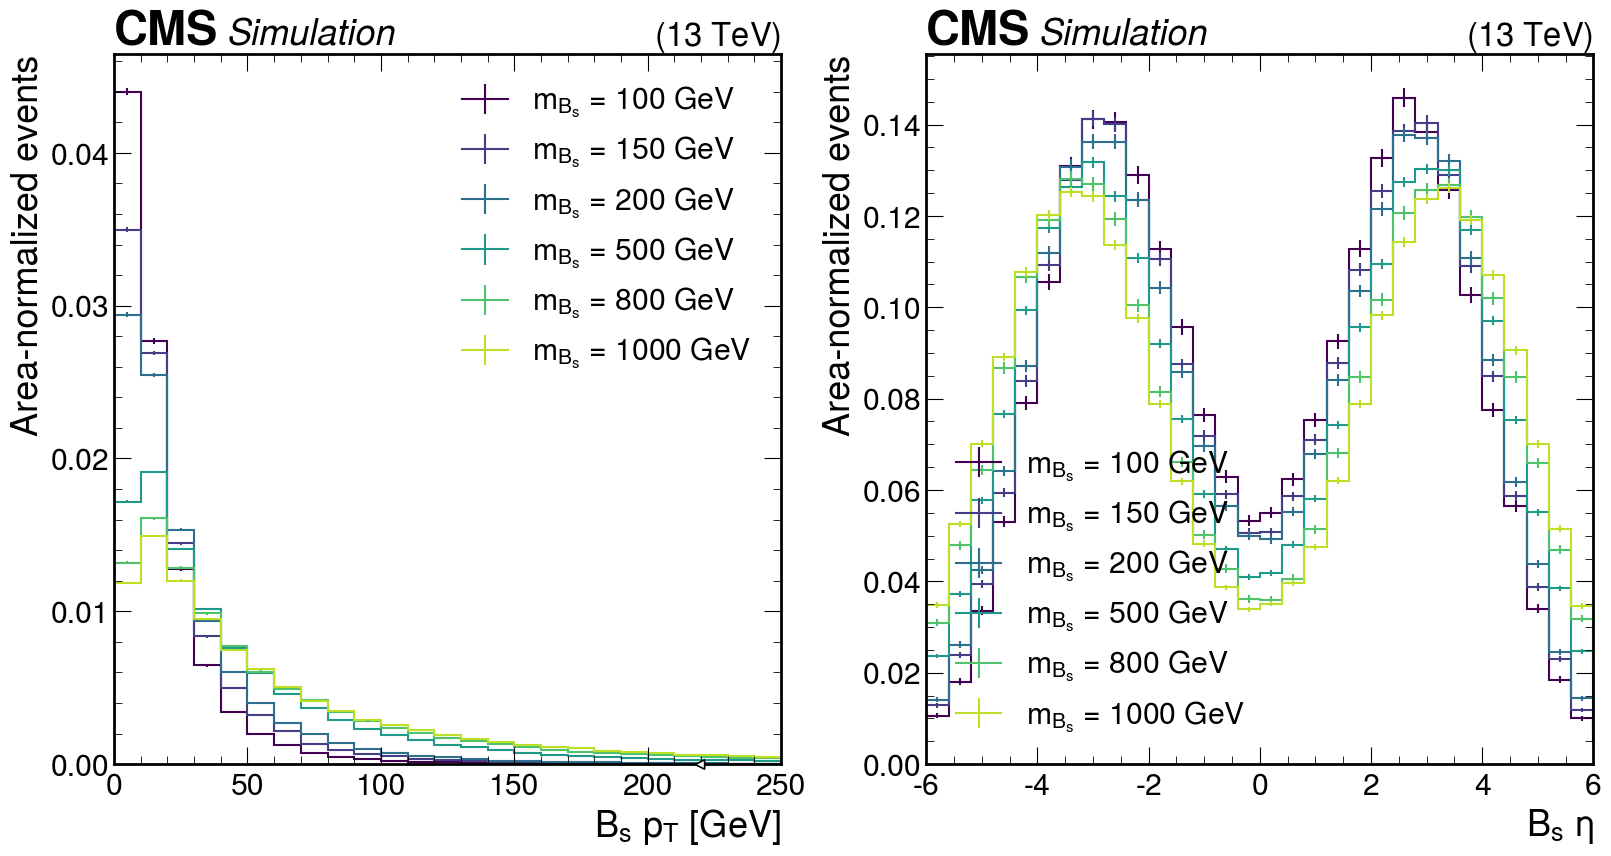

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mbs_scan("genBS_pt"))
ax1.set_xlabel(r"$B_s$ $p_T$ [GeV]")
ax1.set_ylabel("Area-normalized events")
ax1.set_xlim(0, 250)
ax1.legend()
overlay(ax2, mbs_scan("genBS_eta"))
ax2.set_xlabel(r"$B_s$ $\eta$")
ax2.set_ylabel("Area-normalized events")
ax2.set_xlim(-6, 6)
ax2.legend()
for ax in (ax1, ax2):
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_production_system")

for m in MBS:
    h = lib.get_h(out, lib.mid_ctau(out, "4Mu", m, 1.2), "genBS_from_genAs_mass")
    peak = h.axes[-1].centers[np.argmax(h.values())]
    print(f"m(Bs) = {m:6g} GeV: m(Zd Zd) peak bin center = {peak:6.0f} GeV")

### Decay composition, and where the absolute rate comes from

The samples are generated with forced decays: in the 4Mu samples every dark
photon decays to $\mu\mu$; in the 2Mu2E samples one decays to $\mu\mu$ and
the other to $ee$ (verified below from the recorded children of every dark
photon in the sample). Branching fractions are therefore **not** simulated
-- they factorize out of every distribution in this study, which is also
why all figures here are area-normalized shapes. Assembling an absolute
signal yield takes three external factors, none of which touches these
shapes:

1. the production cross section $\sigma(m_{B_s};\ \mathrm{model})$ from the
   ported pseudoscalar-darkonium calculation
   (`sidm/studies/pseudoscalar_xsec`) -- the framework currently carries a
   1 fb placeholder for all signal (`sidm/configs/cross_sections.yaml`);
2. the dark-photon branching fractions to $\mu\mu$/$ee$ at each $m_{Z_d}$
   (same calculation), combined with the forced-decay channel
   combinatorics;
3. the central production-filter efficiency per sample
   (`central_genFilterEfficiencies.yml`; the stored sum of weights is
   post-filter -- see the README's normalization warning).

In [3]:
for mode in ["4Mu", "2Mu2E"]:
    h = lib.get_h(out, lib.mid_ctau(out, mode, 200.0, 1.2), "genAs_children_absPdgId")
    vals, centers = h.values(), h.axes[-1].centers
    tot = vals.sum()
    f_e = vals[(centers > 10) & (centers < 12)].sum() / tot
    f_mu = vals[(centers > 12) & (centers < 14)].sum() / tot
    print(f"{mode}: Zd children |pdgId| = 11 (e): {f_e:.3f}, "
          f"= 13 (mu): {f_mu:.3f}, other: {1 - f_e - f_mu:.3g}")

4Mu: Zd children |pdgId| = 11 (e): 0.000, = 13 (mu): 1.000, other: 0
2Mu2E: Zd children |pdgId| = 11 (e): 0.500, = 13 (mu): 0.500, other: 0


## 2. Back-to-back dark photons and their momentum scale

With the bound state nearly at rest, the two dark photons recoil against each
other: $|\Delta\phi(Z_d, Z_d)|$ piles up at $\pi$, broadening only slightly
with the bound-state $p_T$. Each dark photon carries
$p_T(Z_d) \approx m_{B_s}/2$ -- the left panel of the second figure shows the
Jacobian-like endpoint moving with the grid -- and since $m_{Z_d}$ is
20-4000 times smaller, the resulting boost
$\beta\gamma \approx m_{B_s}/(2 m_{Z_d})$ (right panel) ranges from ~10 in
the (100 GeV, 5 GeV) corner to ~2000 at (1000 GeV, 0.25 GeV). This one number
controls both the collimation (section 4) and the lab-frame decay length
(section 7).

*Samples: 4Mu, middle lifetimes; channel `genOnly` (no cuts).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_backtoback_ptscale.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_boost.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_boost.pdf'

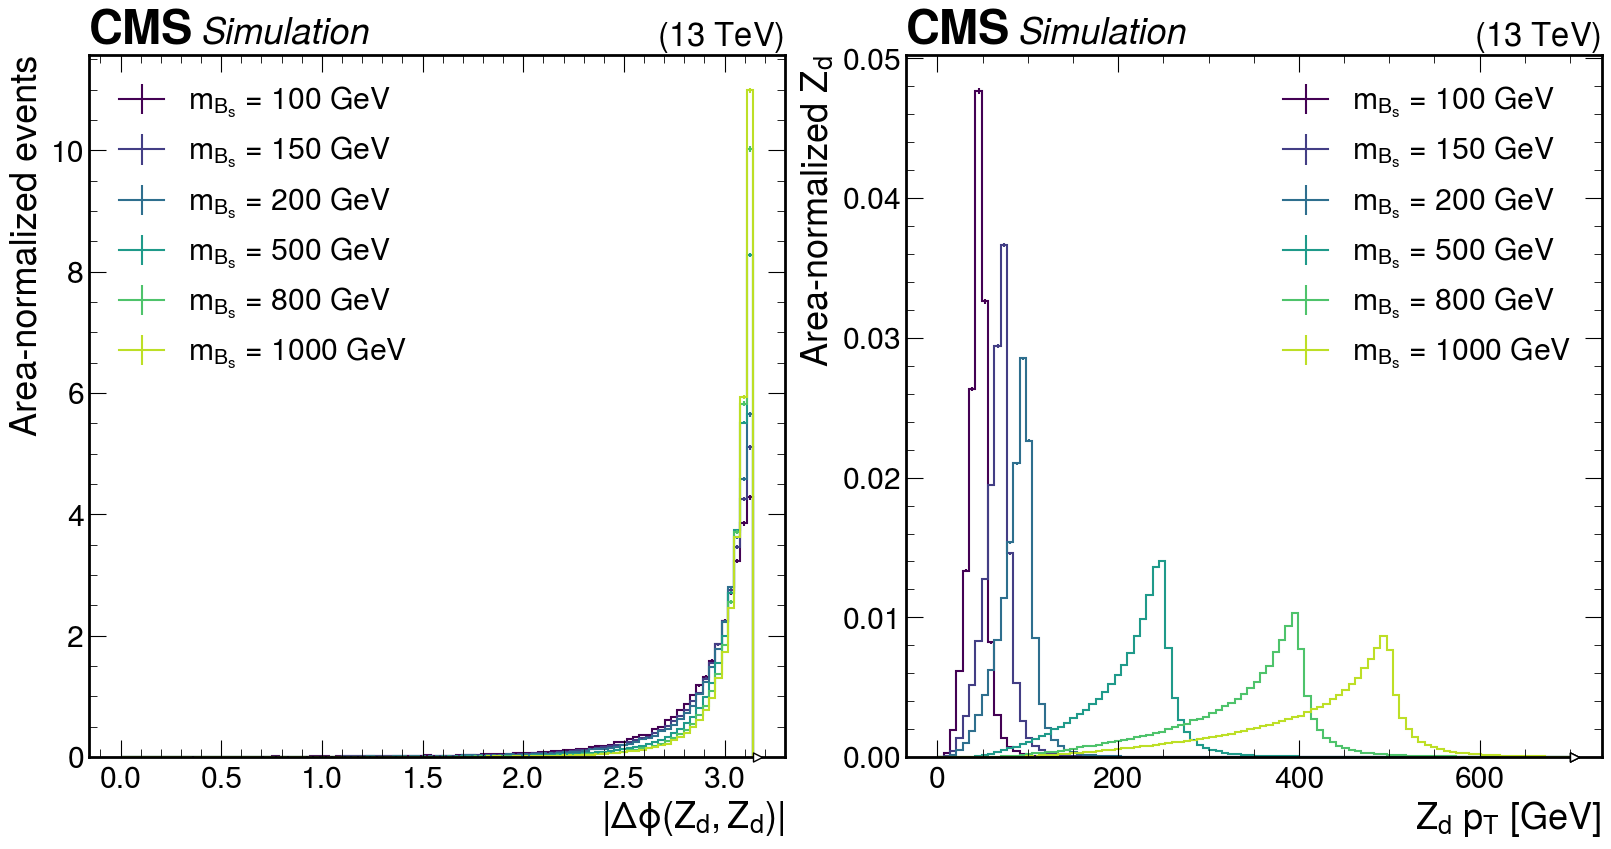

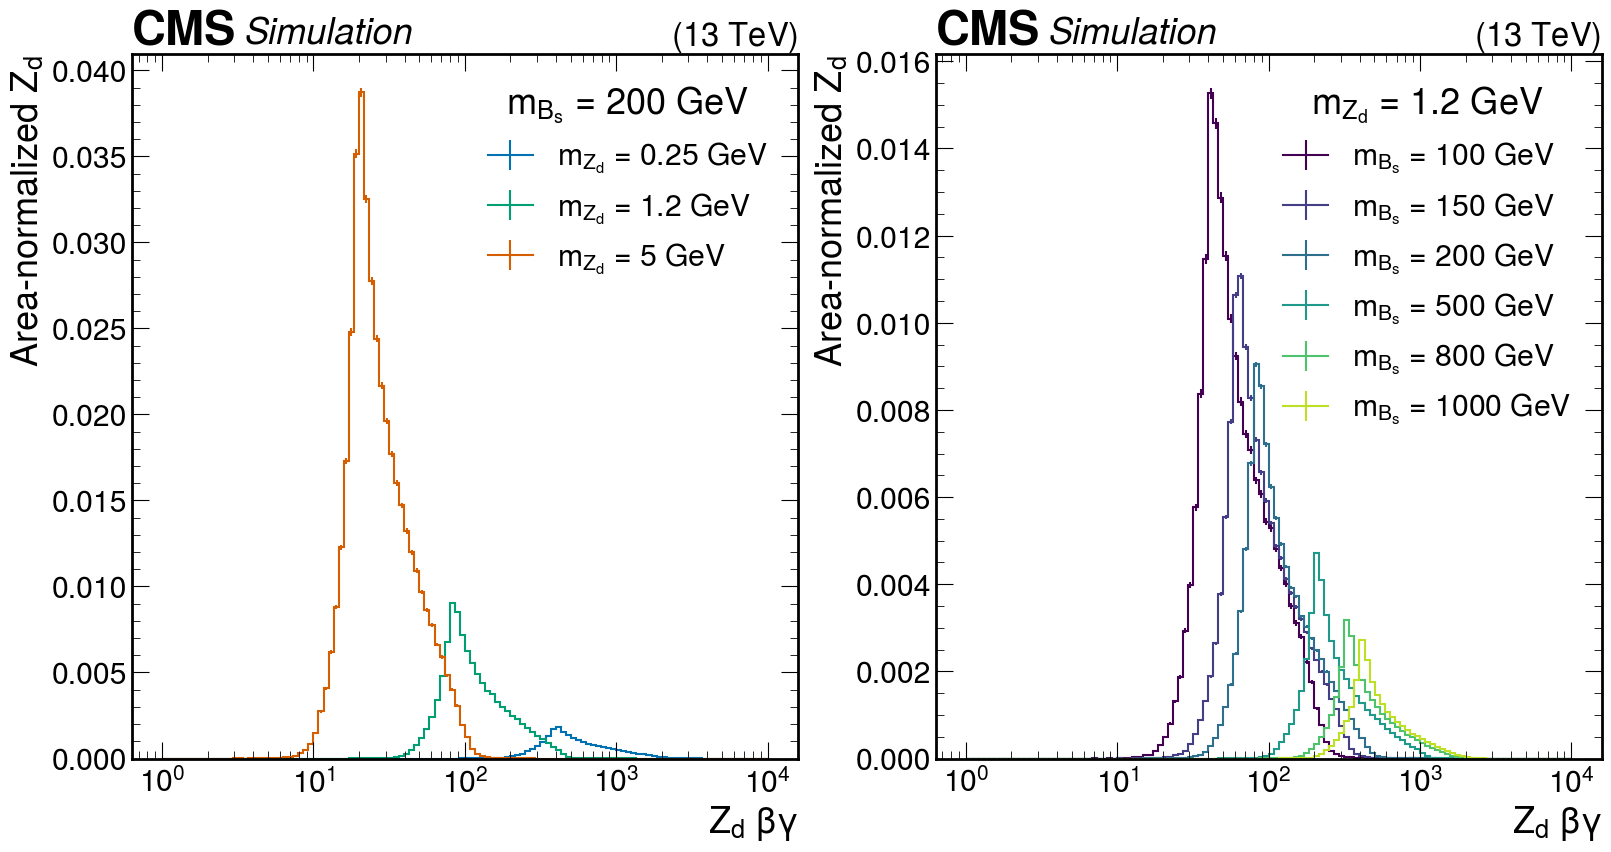

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mbs_scan("genAs_genAs_absdphi"))
ax1.set_xlabel(r"$|\Delta\phi(Z_d, Z_d)|$")
ax1.set_ylabel("Area-normalized events")
ax1.legend(loc="upper left")
overlay(ax2, mbs_scan("genAs_pt_highRange"))
ax2.set_xlabel(r"$Z_d$ $p_T$ [GeV]")
ax2.set_ylabel(r"Area-normalized $Z_d$")
ax2.legend()
for ax in (ax1, ax2):
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_backtoback_ptscale")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mzd_scan("genAs_betagamma", mbs=200.0))
ax1.set_xlabel(r"$Z_d$ $\beta\gamma$")
ax1.set_ylabel(r"Area-normalized $Z_d$")
ax1.set_xscale("log")
ax1.legend(title=r"$m_{B_s}$ = 200 GeV")
overlay(ax2, mbs_scan("genAs_betagamma"))
ax2.set_xlabel(r"$Z_d$ $\beta\gamma$")
ax2.set_ylabel(r"Area-normalized $Z_d$")
ax2.set_xscale("log")
ax2.legend(title=r"$m_{Z_d}$ = 1.2 GeV")
for ax in (ax1, ax2):
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_boost")

## 3. Self-consistency: the masses are where they must be

**Generator level.** The invariant mass of the four status-1 signal leptons
reproduces $m_{B_s}$ (left: 4Mu; right: 2Mu2E). The peaks sit exactly on the
grid values; the asymmetric tail to lower mass is final-state radiation,
visibly larger in the 2Mu2E channel because electrons radiate much more than
muons. (Leading-$p_T$ leptons are used, so shower-conversion leptons enter only
at the few-per-mille level -- the small comb above the peaks.)

The per-pair mass check uses the dark photon's direct daughters: their
4-vector sum reproduces the stored $Z_d$ exactly (momentum conservation at
the decay vertex, before any radiation off the leptons), so
$m(\ell\ell)$ is a delta function at $m_{Z_d}$ -- a construction check
rather than a physics distribution, printed below. The underlying
histogram sums all direct daughters of a flavor in the event, so the check
is read from the 2Mu2E samples, where each flavor tags exactly one dark
photon (in 4Mu the same sum spans both dark photons and reconstructs
$m_{B_s}$ instead).

*Samples: middle lifetimes; channel `genOnly` (no cuts).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_4l_invmass.pdf
m(Zd) = 0.25 GeV: m(mumu) from direct daughters peaks at  0.25 GeV
m(Zd) = 0.25 GeV: m(ee) from direct daughters peaks at  0.25 GeV
m(Zd) =  1.2 GeV: m(mumu) from direct daughters peaks at  1.25 GeV
m(Zd) =  1.2 GeV: m(ee) from direct daughters peaks at  1.25 GeV
m(Zd) =    5 GeV: m(mumu) from direct daughters peaks at  5.05 GeV
m(Zd) =    5 GeV: m(ee) from direct daughters peaks at  5.05 GeV


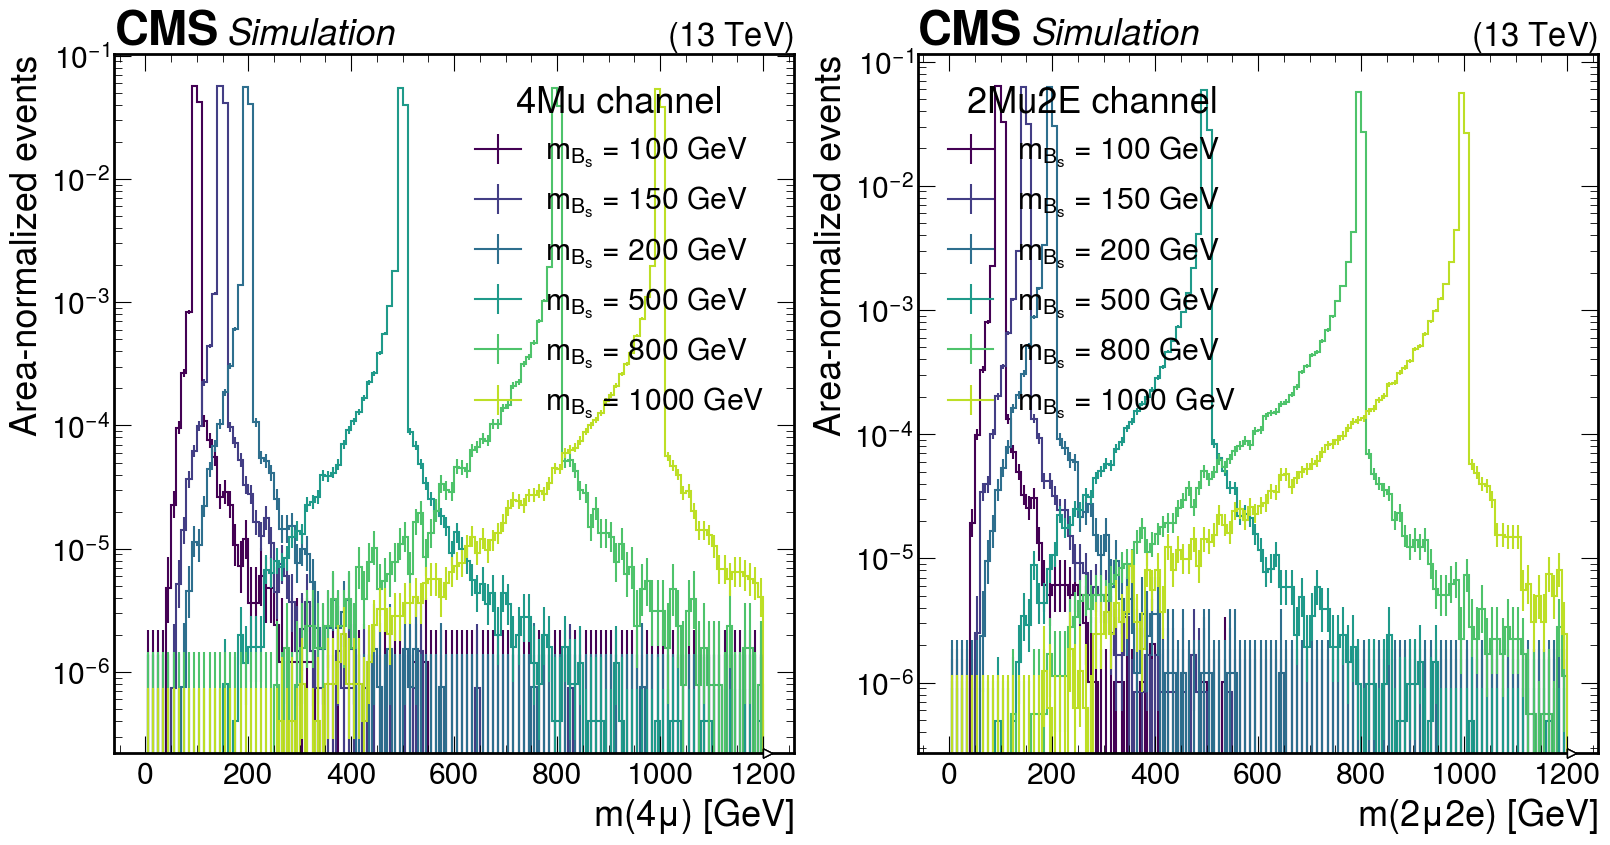

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mbs_scan("gen4Mu_invmass", mode="4Mu"))
ax1.set_xlabel(r"$m(4\mu)$ [GeV]")
ax1.set_ylabel("Area-normalized events")
ax1.set_yscale("log")
ax1.legend(title="4Mu channel")
overlay(ax2, mbs_scan("gen2Mu2E_invmass", mode="2Mu2E"))
ax2.set_xlabel(r"$m(2\mu 2e)$ [GeV]")
ax2.set_ylabel("Area-normalized events")
ax2.set_yscale("log")
ax2.legend(title="2Mu2E channel")
for ax in (ax1, ax2):
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_4l_invmass")

for mzd in MZD:
    s = lib.mid_ctau(out, "2Mu2E", 200.0, mzd)
    for hname, pair in [("genA_from_genMus_mass", "mumu"),
                        ("genA_from_genEs_mass", "ee")]:
        h = lib.get_h(out, s, hname)
        peak = h.axes[-1].centers[np.argmax(h.values())]
        print(f"m(Zd) = {mzd:4g} GeV: m({pair}) from direct daughters "
              f"peaks at {peak:5.2f} GeV")

**Reconstruction level.** The same two statements survive reconstruction: the
invariant mass of the two leading lepton jets peaks at $m_{B_s}$ in the 4Mu
channel and the muon-jet--electron-jet pair mass does the same in 2Mu2E
(left panels -- the softer peaks and low-side tails reflect momentum
resolution, dominated by displaced-standalone muons and electron
bremsstrahlung, plus out-of-cone losses), and each lepton jet's $p_T$ tracks
its matched dark photon's, $p_T(\mathrm{LJ})/p_T(Z_d)$ peaking at unity
(right). The response is not perfect and degrades with the boost: the
fraction of matches with $p_T(\mathrm{LJ})/p_T(Z_d) < 0.8$, printed below,
grows from 7% at $m_{B_s} = 100$ GeV to 37% at 1000 GeV -- the same regime
where the pair-mass resolution visibly widens.

*Channel `base`: dimuon trigger + PV filter + $\geq 2$ lepton jets with
$p_T > 30$ GeV, $|\eta| < 2.4$. These are the loosest reconstruction-level
selections of the analysis, stated here because reconstruction requires an
event selection, unlike the generator-level figures above.*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_reco_selfconsistency.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_reco_2mu2e_pairmass.pdf
m(Bs) =    100 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.07
m(Bs) =    150 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.09
m(Bs) =    200 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.11
m(Bs) =    500 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.21
m(Bs) =    800 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.31
m(Bs) =   1000 GeV: frac(pT(LJ)/pT(Zd) < 0.8) = 0.37


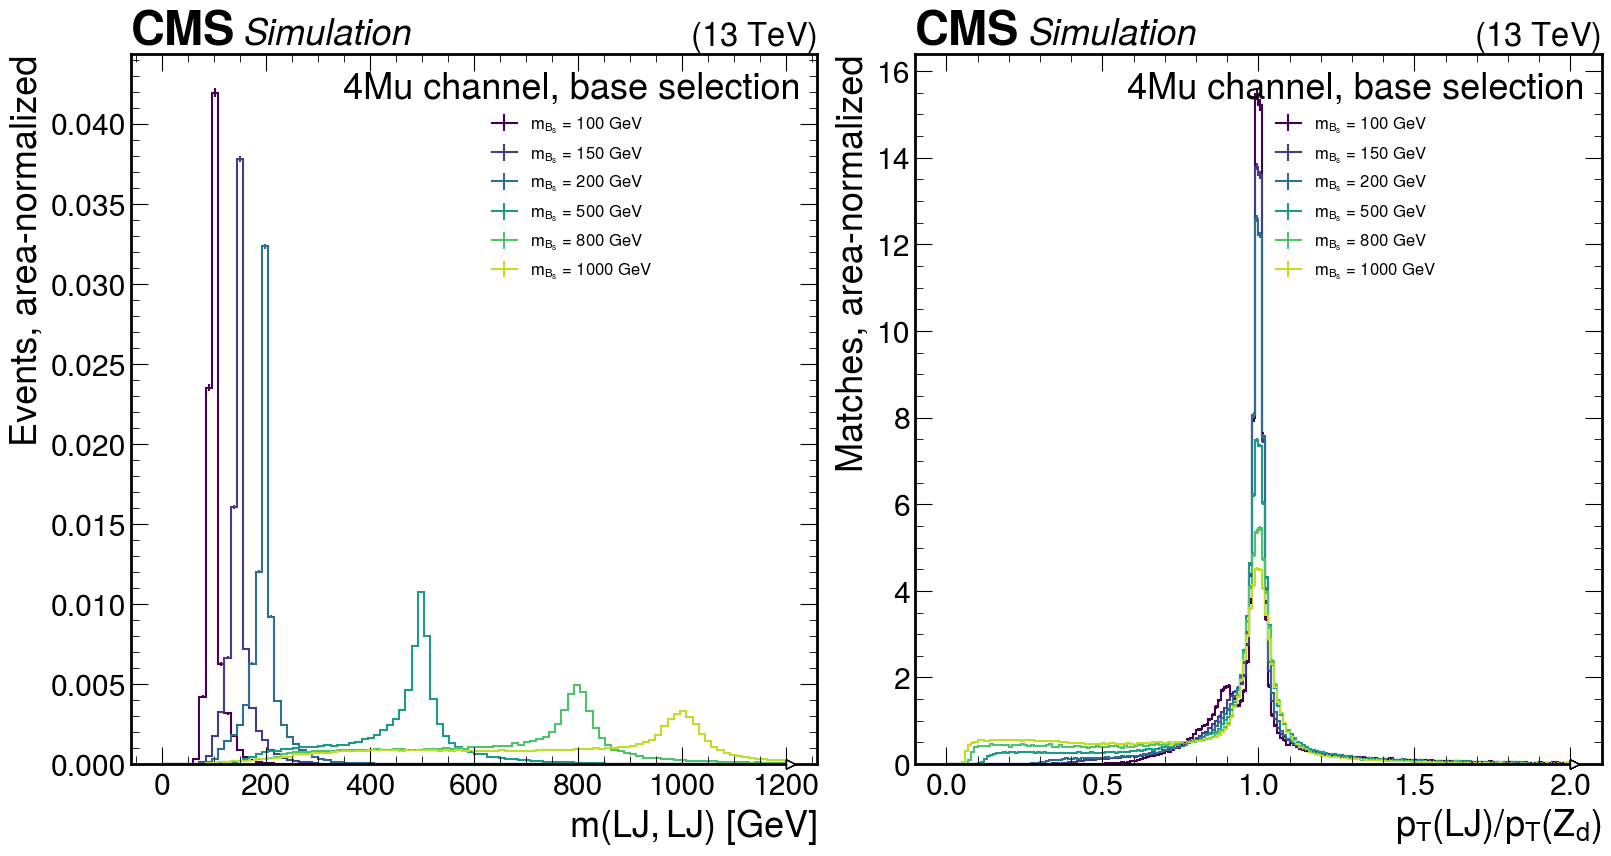

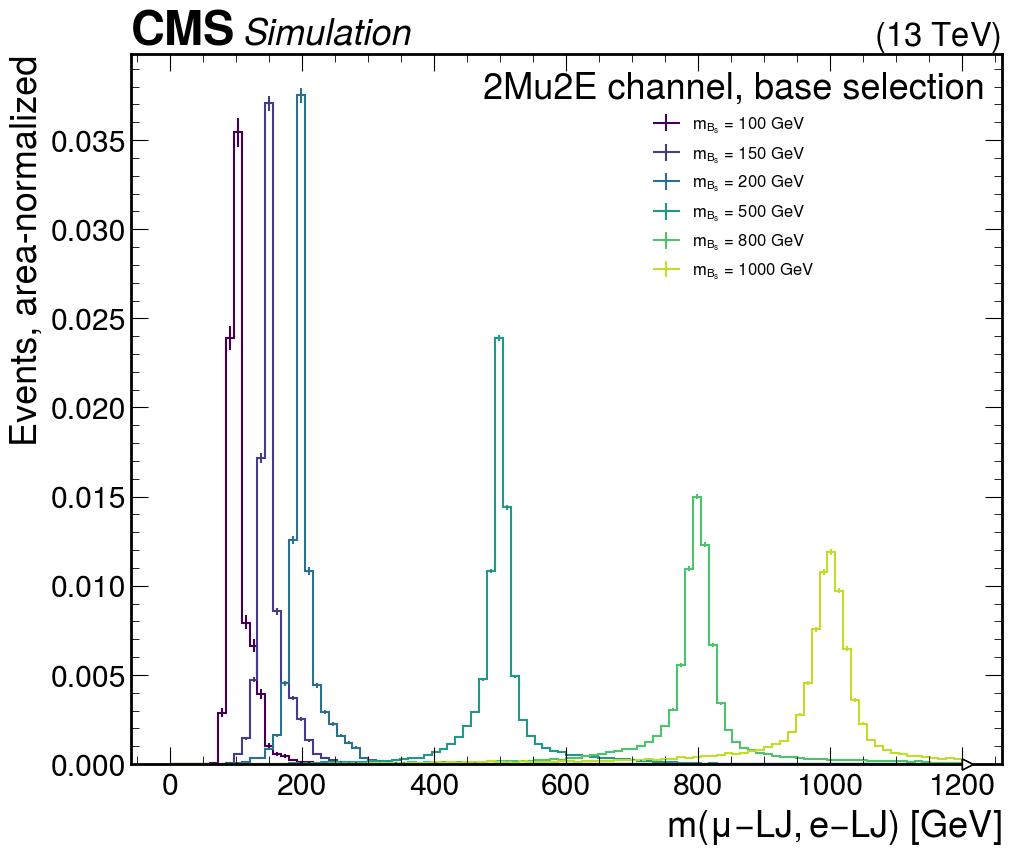

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mbs_scan("lj_lj_invmass", mode="4Mu", channel="base"))
ax1.set_xlabel(r"$m(\mathrm{LJ}, \mathrm{LJ})$ [GeV]")
ax1.set_ylabel("Events, area-normalized")
ax1.legend(title="4Mu channel, base selection", fontsize=12)
overlay(ax2, mbs_scan("genA_lj_ptRatio", mode="4Mu", channel="base"))
ax2.set_xlabel(r"$p_T(\mathrm{LJ}) / p_T(Z_d)$")
ax2.set_ylabel("Matches, area-normalized")
ax2.legend(title="4Mu channel, base selection", fontsize=12)
for ax in (ax1, ax2):
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_reco_selfconsistency")

fig, ax = plt.subplots(figsize=an_style.SINGLE, layout="constrained")
overlay(ax, mbs_scan("mulj_egmlj_invmass", mode="2Mu2E", channel="base"))
ax.set_xlabel(r"$m(\mu\mathrm{-LJ}, e\mathrm{-LJ})$ [GeV]")
ax.set_ylabel("Events, area-normalized")
ax.legend(title="2Mu2E channel, base selection", fontsize=12)
an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_reco_2mu2e_pairmass")

for m in MBS:
    h = lib.get_h(out, lib.mid_ctau(out, "4Mu", m, 1.2), "genA_lj_ptRatio", "base")
    vals, edges = h.values(), h.axes[-1].edges
    below = vals[edges[:-1] < 0.8].sum()
    tot = vals.sum()
    print(f"m(Bs) = {m:6g} GeV: frac(pT(LJ)/pT(Zd) < 0.8) = {below / tot:.2f}")

## 4. Collimation: why these are lepton *jets*

The opening angle between the two daughters of a dark photon is set by the
boost: $\Delta R(\ell,\ell) \approx 2 \beta^* m_{Z_d} / p_T(Z_d)$, where
$\beta^* = \sqrt{1 - 4 m_\ell^2/m_{Z_d}^2}$ is the daughter velocity in the
pair rest frame ($\approx 1$ everywhere except muons at
$m_{Z_d} = 0.25$ GeV, where $\beta^* = 0.53$ -- the same velocity factor
that appears in the asymmetry section below). The left panel scans
$m_{Z_d}$ at fixed $m_{B_s}$: collimation tightens with falling mass, and
faster than linearly on the 1.2 $\to$ 0.25 GeV step because $\beta^*$
drops too. The right panel scans $m_{B_s}$ at fixed $m_{Z_d}$ (collimation
tightens as the boost grows). The grid medians sit inside the
$\Delta R = 0.4$ clustering cone (dashed line) by a factor $\sim 700$ at
(1000, 0.25) GeV down to $\sim 1.5$ at (100, 5) GeV, where a non-negligible
tail leaks outside the cone -- quantified with the grid map below.

*Per dark photon, from its recorded daughters -- immune to the wrong-pairing
ambiguity of event-level lepton pairs in the 4Mu channel. Samples: middle
lifetimes; channel `genOnly` (no cuts).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_collimation_scans.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_collimation_scans.pdf'

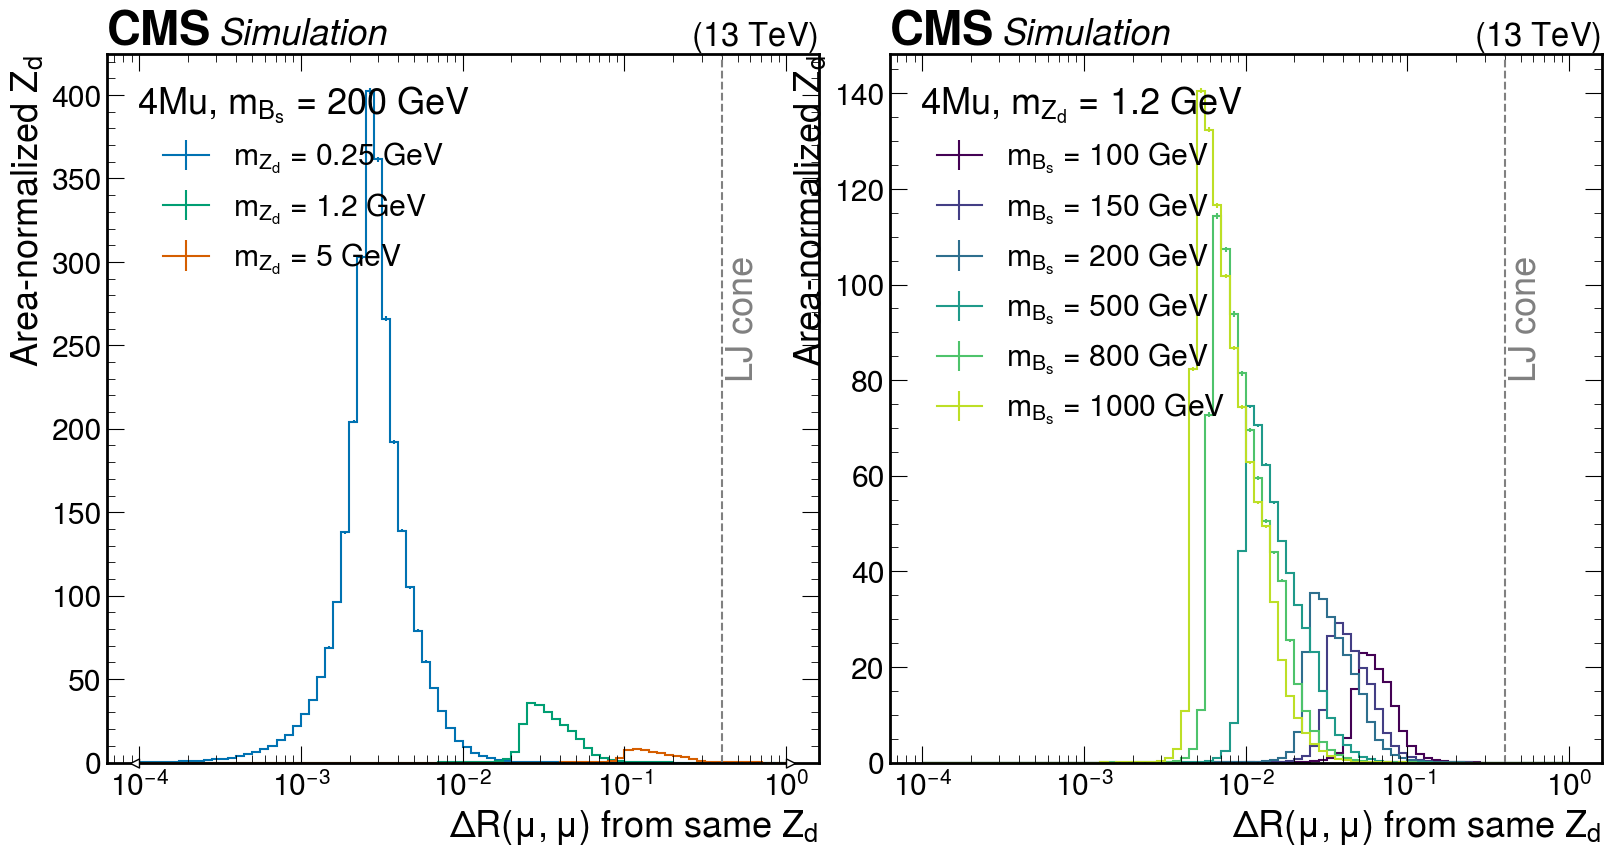

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mzd_scan("genA_toMu_daughters_dR_logx", mbs=200.0))
ax1.legend(title=r"4Mu, $m_{B_s}$ = 200 GeV", loc="upper left")
overlay(ax2, mbs_scan("genA_toMu_daughters_dR_logx"))
ax2.legend(title=r"4Mu, $m_{Z_d}$ = 1.2 GeV", loc="upper left")
for ax in (ax1, ax2):
    ax.set_xscale("log")
    ax.axvline(0.4, color="gray", ls="--")
    ax.text(0.42, 0.55, "LJ cone", rotation=90, color="gray",
            transform=ax.get_xaxis_transform())
    ax.set_xlabel(r"$\Delta R(\mu, \mu)$ from same $Z_d$")
    ax.set_ylabel(r"Area-normalized $Z_d$")
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_collimation_scans")

The two-dimensional view makes the mechanism explicit: per dark photon,
$\Delta R(\ell,\ell)$ against $p_T(Z_d)$ follows the
$2 \beta^* m_{Z_d}/p_T$ curve (dashed) over the full momentum range, for a
tight corner (left, muons at $\beta^* = 0.53$) and the widest corner
(right, electrons at $\beta^* \approx 1$). The spread around the curve is
the $\cos\theta^*$ dependence of the decay, not resolution -- there is no
detector here.

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_collimation_2d.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_collimation_2d.pdf'

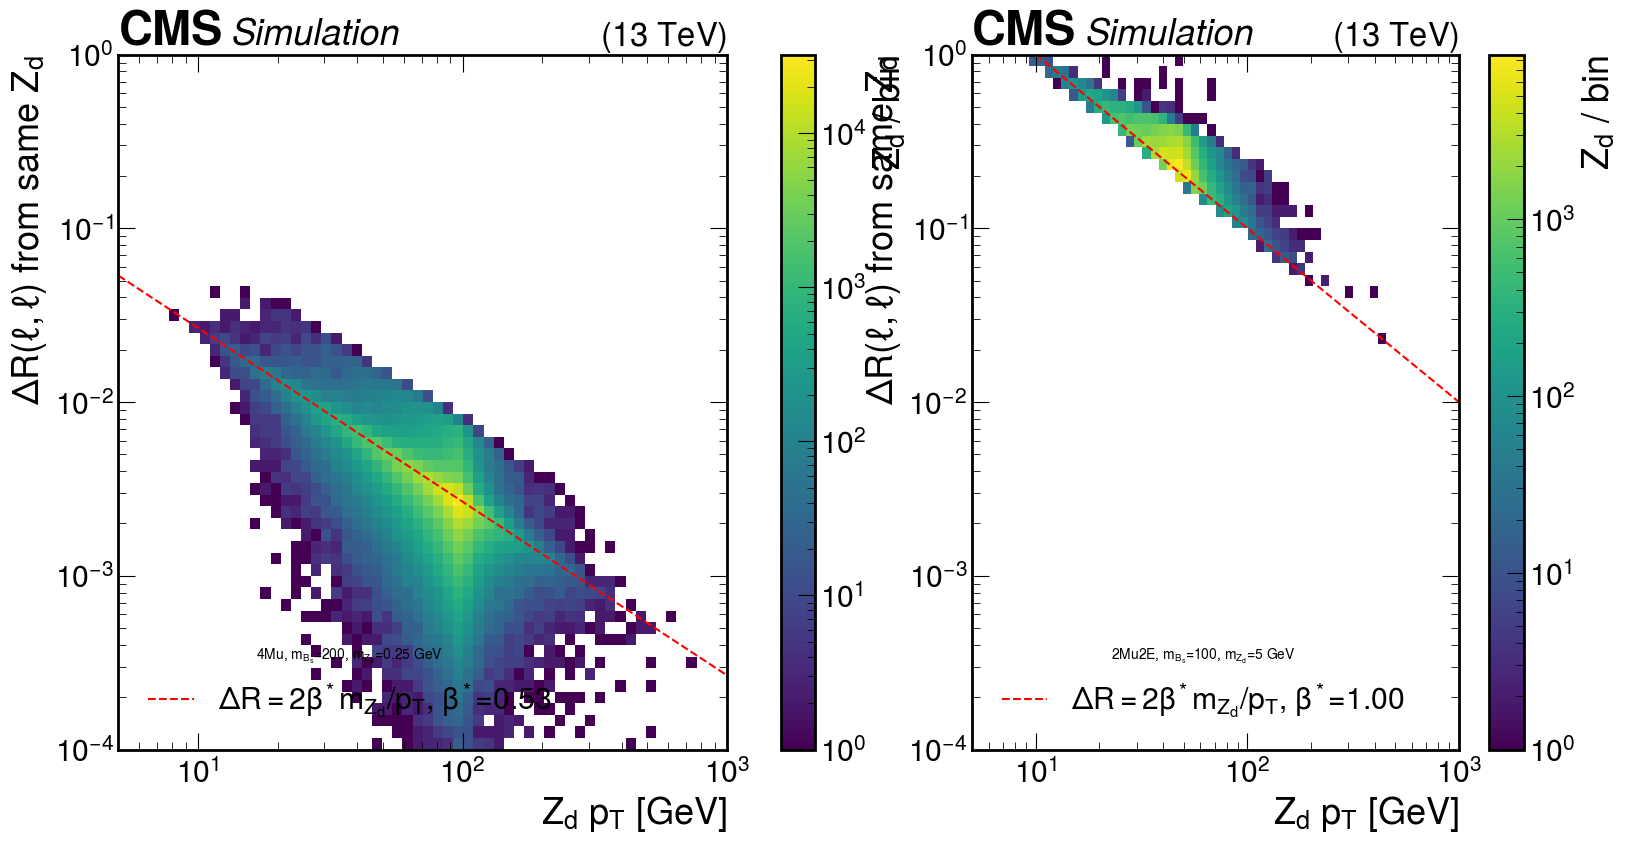

In [8]:
picks = [("4Mu", 200.0, 0.25, r"4Mu, $m_{B_s}$=200, $m_{Z_d}$=0.25 GeV",
          "genA_toMu_daughters_dR_vs_pt"),
         ("2Mu2E", 100.0, 5.0, r"2Mu2E, $m_{B_s}$=100, $m_{Z_d}$=5 GeV",
          "genA_toE_daughters_dR_vs_pt")]
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, (mode, mbs, mzd, title, hname) in zip(axes, picks):
    h = lib.get_h(out, lib.mid_ctau(out, mode, mbs, mzd), hname)
    vals = h.values()
    xe, ye = h.axes[0].edges, h.axes[1].edges
    pcm = ax.pcolormesh(xe, ye, vals.T, norm=LogNorm(vmin=1), cmap="viridis")
    fig.colorbar(pcm, ax=ax, label=r"$Z_d$ / bin")
    m_lep = 0.105658 if "toMu" in hname else 0.000511
    beta_star = np.sqrt(1 - 4 * m_lep**2 / mzd**2)
    pts = np.geomspace(max(xe[0], 2 * mzd), xe[-1], 200)
    ax.plot(pts, 2 * beta_star * mzd / pts, "--", color="red",
            label=rf"$\Delta R = 2\beta^* m_{{Z_d}}/p_T$, $\beta^*$={beta_star:.2f}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$Z_d$ $p_T$ [GeV]")
    ax.set_ylabel(r"$\Delta R(\ell, \ell)$ from same $Z_d$")
    ax.legend(loc="lower left", title=title, title_fontsize=10)
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_collimation_2d")

The grid summary: median $\Delta R(\mu,\mu)$ per mass point in the 4Mu
samples (all five lifetimes combined -- the opening angle does not depend
on lifetime). The medians span 0.0006 to 0.27, a factor $\sim 700$ down to
$\sim 1.5$ inside the clustering cone. The fixed $\Delta R = 0.4$
lepton-jet definition is therefore comfortable over most of the grid, with
one marginal corner: at $m_{Z_d} = 5$ GeV and the lightest bound states an
appreciable fraction of pairs (up to $\sim 8$% at (100, 5) GeV) opens
beyond the cone -- printed below, since this is exactly where the cone
choice costs signal.

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_collimation_grid.pdf
grid median DeltaR range: 0.0006 - 0.264 (cone: 0.4)
4Mu mBs=100 mZd=5: frac(dR > 0.4) = 0.078
4Mu mBs=150 mZd=5: frac(dR > 0.4) = 0.016
4Mu mBs=200 mZd=5: frac(dR > 0.4) = 0.005
2Mu2E mBs=100 mZd=5: frac(dR > 0.4) = 0.078
2Mu2E mBs=150 mZd=5: frac(dR > 0.4) = 0.016
2Mu2E mBs=200 mZd=5: frac(dR > 0.4) = 0.005


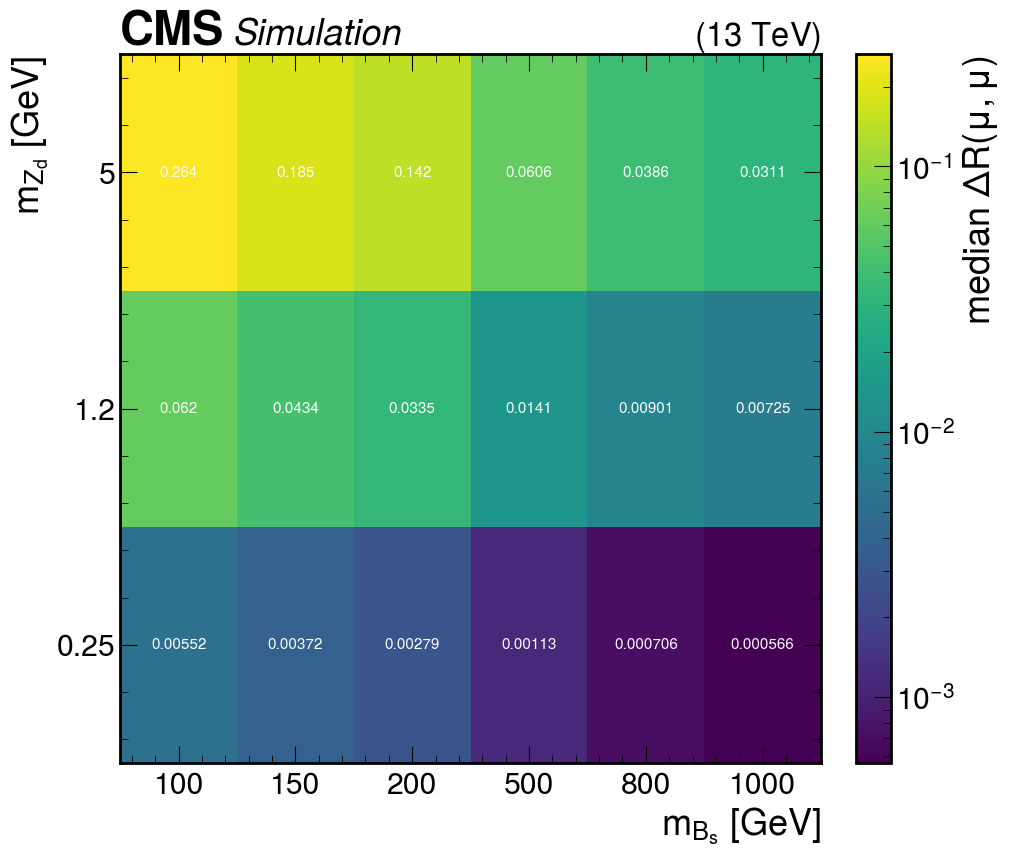

In [9]:
grid = np.zeros((len(MZD), len(MBS)))
for i, mzd in enumerate(MZD):
    for j, mbs in enumerate(MBS):
        names = lib.select_samples(out, mode="4Mu", mbs=mbs, mzd=mzd)
        grid[i, j] = lib.hist_median(lib.sum_h(out, names, "genA_toMu_daughters_dR_logx"))

fig, ax = plt.subplots(figsize=an_style.SINGLE, layout="constrained")
pcm = ax.pcolormesh(np.arange(len(MBS) + 1), np.arange(len(MZD) + 1), grid,
                    norm=LogNorm(), cmap="viridis")
fig.colorbar(pcm, ax=ax, label=r"median $\Delta R(\mu, \mu)$")
for i in range(len(MZD)):
    for j in range(len(MBS)):
        ax.text(j + 0.5, i + 0.5, f"{grid[i, j]:.3g}", ha="center", va="center",
                color="white", fontsize=11)
ax.set_xticks(np.arange(len(MBS)) + 0.5, [f"{m:g}" for m in MBS])
ax.set_yticks(np.arange(len(MZD)) + 0.5, [f"{m:g}" for m in MZD])
ax.set_xlabel(r"$m_{B_s}$ [GeV]")
ax.set_ylabel(r"$m_{Z_d}$ [GeV]")
an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_collimation_grid")
print(f"grid median DeltaR range: {grid.min():.4f} - {grid.max():.3f} (cone: 0.4)")

# out-of-cone leakage where the cone is marginal (0.4 is a bin edge of the
# 0-1 daughters-dR axis, so the split is exact)
for mode, hname in [("4Mu", "genA_toMu_daughters_dR"), ("2Mu2E", "genA_toE_daughters_dR")]:
    for mbs in [100.0, 150.0, 200.0]:
        names = lib.select_samples(out, mode=mode, mbs=mbs, mzd=5.0)
        h = lib.sum_h(out, names, hname)
        vals, edges = h.values(flow=True), h.axes[-1].edges
        # flow array: index 0 = underflow, so bin i sits at index i + 1
        above = vals[np.searchsorted(edges, 0.4) + 1:].sum()  # includes overflow
        print(f"{mode} mBs={mbs:g} mZd=5: frac(dR > 0.4) = {above / vals.sum():.3f}")

## 5. The boost is what makes the leptons hard

The lepton momenta are pure kinematics: each dark photon carries
$\approx m_{B_s}/2$, split between two daughters, so the leading (left) and
sub-leading (right) muon $p_T$ scale with the bound-state mass at roughly
$m_{B_s}/4$ per lepton, spread by the decay angle. A sub-GeV mediator still
yields tens-of-GeV leptons -- this is why the light-$Z_d$ corners are
triggerable at all. The vertical lines mark the HLT dimuon thresholds
(23/25 GeV); the interplay with the triggers, including efficiency
turn-ons, is treated in `trigger_context_forAN.ipynb`.

*Samples: 4Mu, $m_{Z_d}$ = 1.2 GeV, middle lifetimes; channel `genOnly`
(no cuts). Event-level leading/sub-leading among the four muons.*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_lepton_pt.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_lepton_pt.pdf'

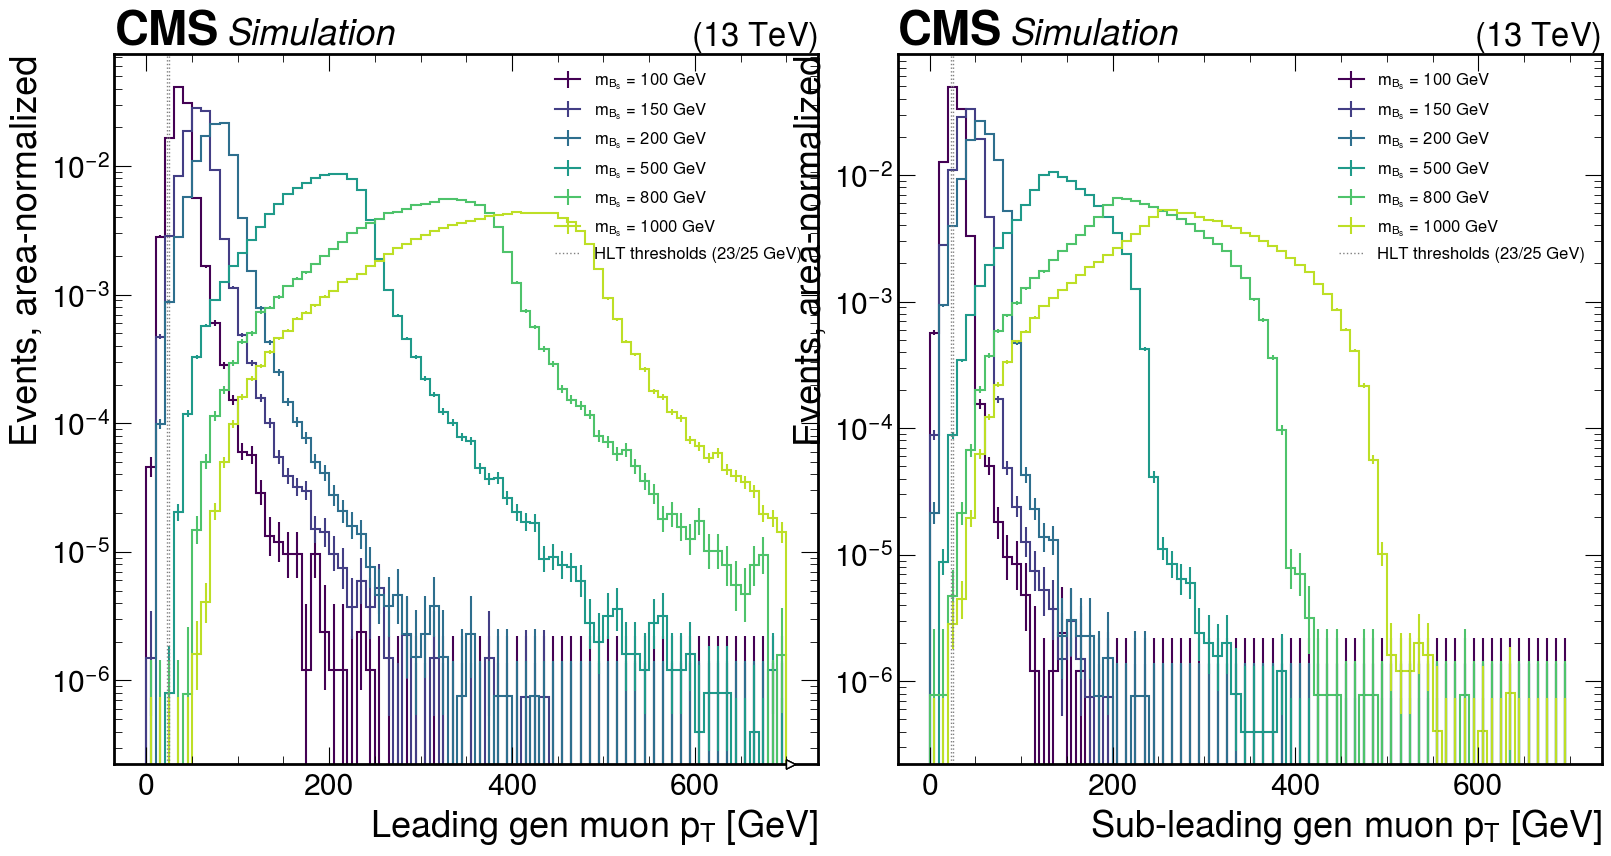

In [10]:
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
overlay(ax1, mbs_scan("genMu0_pt_highRange"))
ax1.set_xlabel(r"Leading gen muon $p_T$ [GeV]")
overlay(ax2, mbs_scan("genMu1_pt_highRange"))
ax2.set_xlabel(r"Sub-leading gen muon $p_T$ [GeV]")
for ax in (ax1, ax2):
    for thr in (23, 25):
        ax.axvline(thr, color="gray", ls=":", lw=1)
    ax.set_ylabel("Events, area-normalized")
    ax.set_yscale("log")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], color="gray", ls=":", lw=1))
    labels.append("HLT thresholds (23/25 GeV)")
    ax.legend(handles, labels, fontsize=12)
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_lepton_pt")

## 6. Lab-frame $p_T$ asymmetry reflects the rest-frame decay alignment

Within a pair, the daughter emitted along the boost direction in the $Z_d$
rest frame takes the larger share of the lab momentum:
$p_T^{\rm sub}/p_T^{\rm lead} \approx (1 - \beta^* c)/(1 + \beta^* c)$ with
$c = |\cos\theta^*|$ the rest-frame decay angle and $\beta^*$ the daughter
velocity in that frame. The figure uses the 2Mu2E samples, where the two
muons entering the ratio are always the one $\mu\mu$ pair (the underlying
histogram ranks all muons in the event, which in the 4Mu channel would mix
the two dark photons' pairs). The ridge of the 2D distribution tracks the
curve (dashed); the population above it comes from the finite $Z_d$ boost
spread. Two consequences:

- **The polarization matters in the lab.** The $Z_d$ is transversely
  polarized ($dN/d\cos\theta^* \propto 1 + \alpha\cos^2\theta^*$; fits in
  `polarization_migration_forAN.ipynb`), which populates large
  $|\cos\theta^*|$ and therefore *asymmetric* pairs -- more events with a
  soft sub-leading lepton than an isotropic decay would give, directly
  relevant for the sub-leading-muon trigger thresholds.
- **The muon mass matters at $m_{Z_d} = 0.25$ GeV.** There
  $\beta^* = \sqrt{1 - 4 m_\mu^2/m_{Z_d}^2} = 0.53$, so the asymmetry
  saturates at $p_T$ ratios of $\sim 0.3$ (right panel): near-threshold
  muon pairs cannot be arbitrarily asymmetric, and the same velocity factor
  suppresses the polarization visible in the decay distribution.

The transverse polarization is itself a prediction of the model's
pseudoscalar coupling structure ($P \to Z_d Z_d$ populates only transverse
polarizations), so the generator-level $\alpha \approx 1$ fits in
`polarization_migration_forAN.ipynb` double as a check that the samples
carry the intended quantum numbers of the calculation in
`sidm/studies/pseudoscalar_xsec`. The depleted band as
$|\cos\theta^*| \to 1$ is the production gen filter (such decays produce a
lepton below its 5 GeV requirement), not a polarization effect.

*Samples: 2Mu2E, $m_{B_s}$ = 200 GeV, middle lifetimes; channel `genOnly`
(only generator-level object definitions -- but see the gen-filter caveat
in the introduction).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_ptratio_costheta.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_ptratio_costheta.pdf'

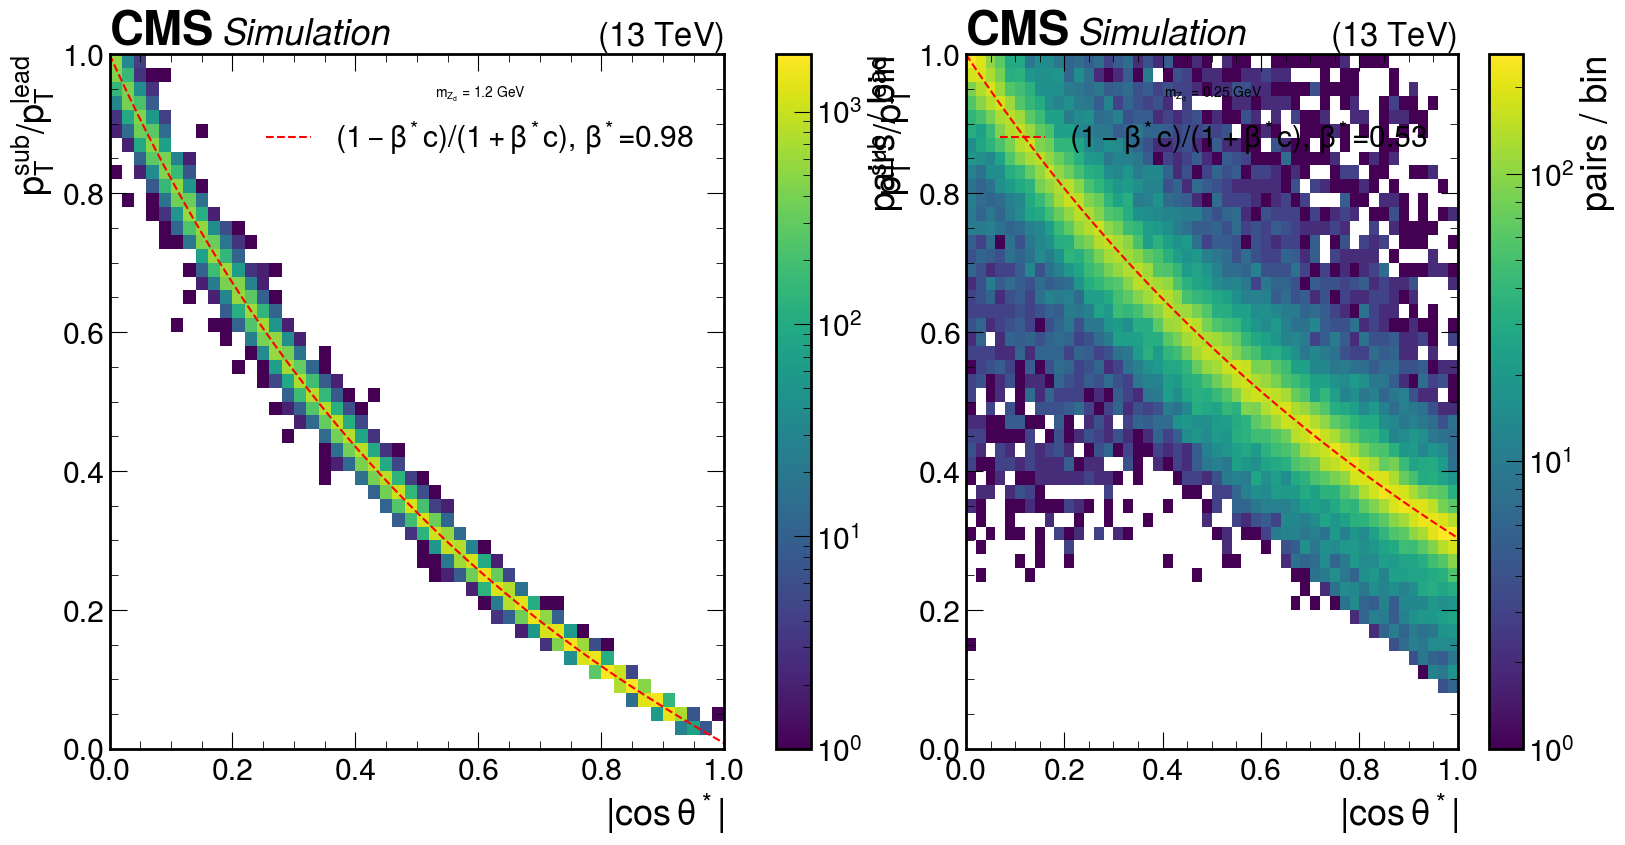

In [11]:
MMU = 0.105658
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, mzd in zip(axes, [1.2, 0.25]):
    h = lib.get_h(out, lib.mid_ctau(out, "2Mu2E", 200.0, mzd),
                  "genMu_ptRatio_vs_absCosTheta")
    vals = h.values()
    xe, ye = h.axes[0].edges, h.axes[1].edges
    pcm = ax.pcolormesh(xe, ye, vals.T, norm=LogNorm(vmin=1), cmap="viridis")
    fig.colorbar(pcm, ax=ax, label="pairs / bin")
    beta_star = np.sqrt(1 - 4 * MMU**2 / mzd**2)
    c = np.linspace(0, 1, 200)
    ax.plot(c, (1 - beta_star * c) / (1 + beta_star * c), "--", color="red",
            label=rf"$(1-\beta^* c)/(1+\beta^* c)$, $\beta^*$={beta_star:.2f}")
    ax.set_xlabel(r"$|\cos\theta^*|$")
    ax.set_ylabel(r"$p_T^{\rm sub} / p_T^{\rm lead}$")
    ax.legend(loc="upper right", title=rf"$m_{{Z_d}}$ = {mzd:g} GeV",
              title_fontsize=10)
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_ptratio_costheta")

## 7. Displacement: the same boost, applied to the lifetime

The lab decay length is $\beta\gamma \, c\tau$: the boost that collimates
the pairs also stretches millimeter proper lifetimes into
centimeter-to-meter transverse displacements. The four samples shown are
the event-display corners of `event_displays_forAN.ipynb`, roughly a decade
of $l_{xy}$ per step (the last step a half-decade; medians printed below).
The per-lepton view of the same physics -- gen $|d_0|$
across the lifetime grid, the quantity the displaced triggers and
reconstruction respond to -- is in `truth_kinematics_forAN.ipynb`, and the
lifetime closure checks are in `lifetime_forAN.ipynb`.

*Channel `genOnly` (no cuts).*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/anatomy_displacement_corners.pdf
2Mu2E_500GeV_1p2GeV_0p019mm: median lxy = 0.229 cm
4Mu_200GeV_1p2GeV_0p48mm: median lxy = 2.34 cm
4Mu_1000GeV_0p25GeV_0p2mm: median lxy = 21.9 cm
2Mu2E_100GeV_5p0GeV_200mm: median lxy = 110 cm


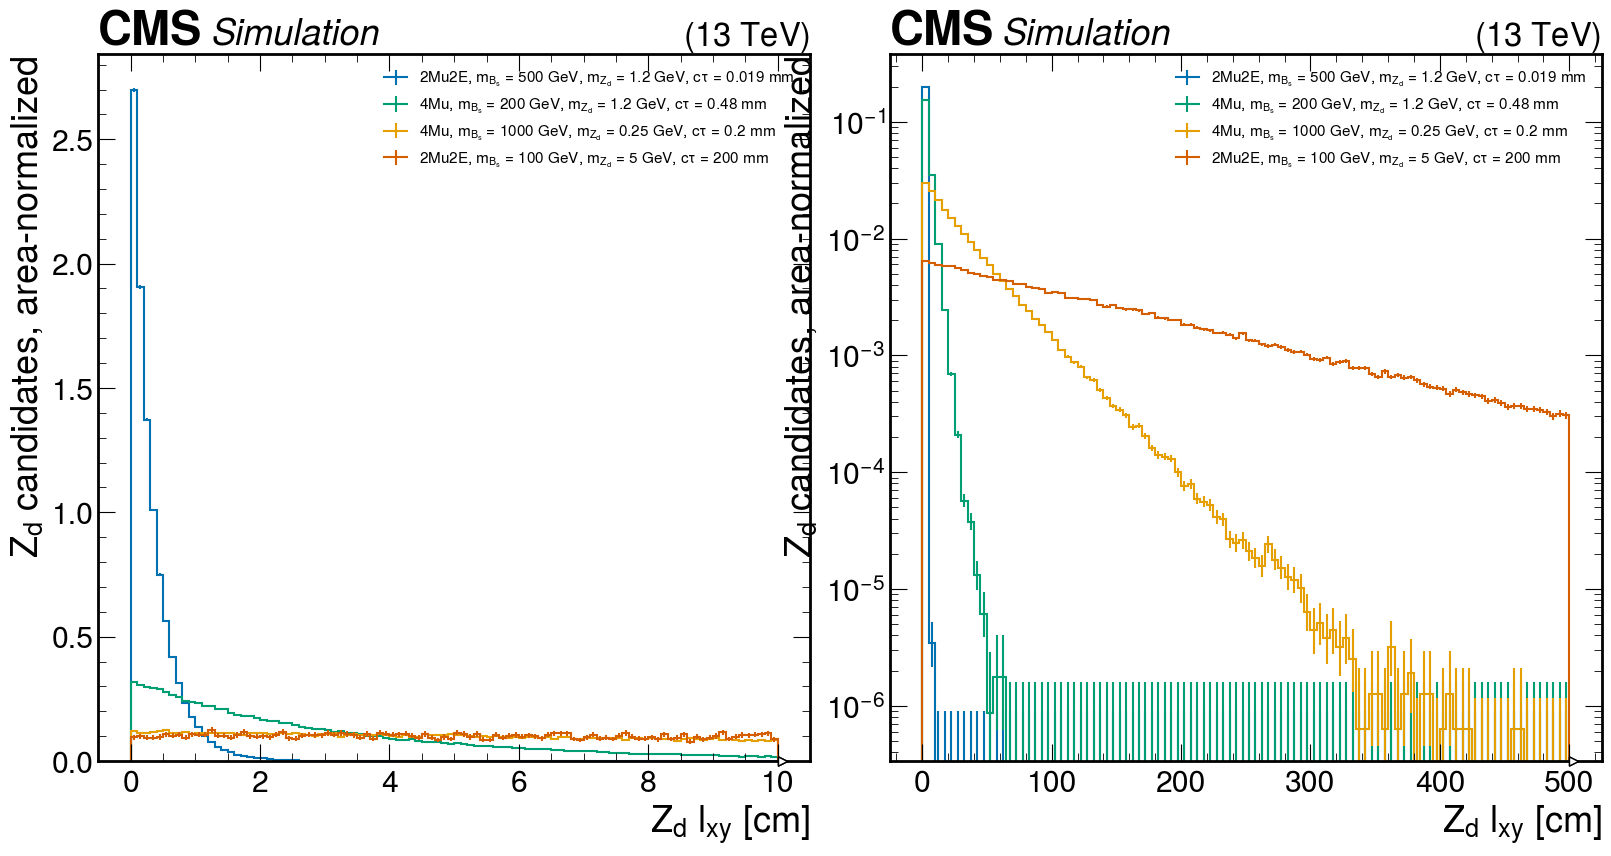

In [12]:
corners = [("2Mu2E_500GeV_1p2GeV_0p019mm", "#0072B2"),
           ("4Mu_200GeV_1p2GeV_0p48mm", "#009E73"),
           ("4Mu_1000GeV_0p25GeV_0p2mm", "#E69F00"),
           ("2Mu2E_100GeV_5p0GeV_200mm", "#D55E00")]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for name, color in corners:
    lab = lib.format_sample(name)
    hep.histplot(lib.get_h(out, name, "genAs_lxy_lowRange"), ax=ax1,
                 density=True, label=lab, color=color)
    hep.histplot(lib.get_h(out, name, "genAs_lxy"), ax=ax2,
                 density=True, label=lab, color=color)
ax1.set_xlabel(r"$Z_d$ $l_{xy}$ [cm]")
ax2.set_xlabel(r"$Z_d$ $l_{xy}$ [cm]")
ax2.set_yscale("log")
for ax in (ax1, ax2):
    ax.set_ylabel(r"$Z_d$ candidates, area-normalized")
    ax.legend(fontsize=11)
    an_style.cms_sim_label(ax)
an_style.save(fig, "anatomy_displacement_corners")
for name, _ in corners:
    med = lib.hist_median_tiered(lib.get_h(out, name, "genAs_lxy_lowRange"),
                                 lib.get_h(out, name, "genAs_lxy"))
    print(f"{name}: median lxy = {med:.3g} cm")

## Summary

One mass hierarchy produces the whole signature. $m_{Z_d} \ll m_{B_s}$ gives
each dark photon a boost of $10$-$10^3$, which (i) collimates each lepton
pair to $\Delta R \approx 2 \beta^* m_{Z_d}/p_T$, a factor $\sim 1.5$ to
$\sim 700$ inside the $\Delta R = 0.4$ clustering cone (with percent-level
out-of-cone leakage only in the (light $B_s$, 5 GeV) corner), (ii) hardens
the leptons to
$\sim m_{B_s}/4$ so even sub-GeV mediators pass tens-of-GeV trigger
thresholds, and (iii) stretches proper lifetimes into displacements
spanning the beampipe to the muon system. The two dark photons emerge
back-to-back, so the event is two lepton jets at $\Delta\phi \approx \pi$
whose pair mass reconstructs $m_{B_s}$ and whose individual kinematics
track the dark photons. These distributions justify, in order: the
lepton-jet object definition, the dimuon trigger strategy and its $p_T$
thresholds (`trigger_context_forAN.ipynb`), and the displacement-based
selections. Single-event illustrations are in `event_displays_forAN.ipynb`.